#### Importing the libaries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('titanic.csv')
df.head()


In [2]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


 there is some missing values that we can see when we see the df.info() . there is 891 rows and 15 columns in data sets.
 age column has some missing data and embarked has also. deck columns has way more missing values need to analzye. also embark_town

##### Analayzing the Data

In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Here, in the age data set the min value is 0.42 which seems not accurate, sibsp and parch max value are way far than mean and sd. so that there must be some outlier in this column,  same as the fare max value is way far thant he 75% which may also be outliers. Therefore, there is some inconsistency  in this datasets

#### Handling Duplicates and MIssing Values

In [4]:
#create the copy of your data
df_copy = df.copy()

In [5]:
duplicates = df_copy.duplicated()
duplicates

0      False
1      False
2      False
3      False
4      False
       ...  
886     True
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

Based on this, we can see that there is some duplicates in data sets which we can drop.

In [7]:
df_copy = df_copy.drop_duplicates()

In [8]:
df_copy

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


After droping we have now 784 rows and 15 columns

In [9]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     784 non-null    int64  
 1   pclass       784 non-null    int64  
 2   sex          784 non-null    str    
 3   age          678 non-null    float64
 4   sibsp        784 non-null    int64  
 5   parch        784 non-null    int64  
 6   fare         784 non-null    float64
 7   embarked     782 non-null    str    
 8   class        784 non-null    str    
 9   who          784 non-null    str    
 10  adult_male   784 non-null    bool   
 11  deck         202 non-null    str    
 12  embark_town  782 non-null    str    
 13  alive        784 non-null    str    
 14  alone        784 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 87.3 KB


In [10]:
#check the missing values
missing_values = df_copy.isnull().sum()
missing_values

survived         0
pclass           0
sex              0
age            106
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           582
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
#check the missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [11]:
#embarked and embark_town has only two missing values we can drop the rows
df_copy = df_copy.dropna(subset=['embarked','embark_town'])
df_copy.info()

<class 'pandas.DataFrame'>
Index: 782 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     782 non-null    int64  
 1   pclass       782 non-null    int64  
 2   sex          782 non-null    str    
 3   age          676 non-null    float64
 4   sibsp        782 non-null    int64  
 5   parch        782 non-null    int64  
 6   fare         782 non-null    float64
 7   embarked     782 non-null    str    
 8   class        782 non-null    str    
 9   who          782 non-null    str    
 10  adult_male   782 non-null    bool   
 11  deck         200 non-null    str    
 12  embark_town  782 non-null    str    
 13  alive        782 non-null    str    
 14  alone        782 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 87.1 KB


In [12]:

df_copy[df_copy['age'].isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.0000,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.2250,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.8792,Q,Third,woman,False,NaN,Queenstown,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
828,1,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,yes,True
839,1,1,male,NaN,0,0,29.7000,C,First,man,True,C,Cherbourg,yes,True
849,1,1,female,NaN,1,0,89.1042,C,First,woman,False,C,Cherbourg,yes,False
868,0,3,male,NaN,0,0,9.5000,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df['deck'].isna()

0       True
1      False
2       True
3      False
4       True
       ...  
886     True
887    False
888     True
889    False
890     True
Name: deck, Length: 891, dtype: bool

In [14]:
df_copy['age_no_null'] = df_copy['age'].fillna(df_copy['age'].mean())


In [13]:
df_copy[df_copy['deck'].isna()]


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
882,0,3,female,22.0,0,0,10.5167,S,Third,woman,False,NaN,Southampton,no,True
883,0,2,male,28.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


In [18]:
df_copy = df_copy.drop(['deck'], axis = 1)

In [19]:
df_copy.info()

<class 'pandas.DataFrame'>
Index: 782 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     782 non-null    int64  
 1   pclass       782 non-null    int64  
 2   sex          782 non-null    str    
 3   age          676 non-null    float64
 4   sibsp        782 non-null    int64  
 5   parch        782 non-null    int64  
 6   fare         782 non-null    float64
 7   embarked     782 non-null    str    
 8   class        782 non-null    str    
 9   who          782 non-null    str    
 10  adult_male   782 non-null    bool   
 11  embark_town  782 non-null    str    
 12  alive        782 non-null    str    
 13  alone        782 non-null    bool   
 14  age_no_null  782 non-null    float64
dtypes: bool(2), float64(3), int64(4), str(6)
memory usage: 87.1 KB


####  Features Engineering


In [20]:
df_copy['pclass'].unique()

array([3, 1, 2])

In [21]:
df_copy['pclass_category'] = df_copy['pclass'].map({1:'High',2: 'Medium',3:'Low'})


In [24]:
df_copy= df_copy.drop(['who','adult_male','alive'], axis = 1)

In [25]:
df_copy

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,embark_town,alone,age_no_null,pclass_category
0,0,3,male,22.0,1,0,7.2500,S,Third,Southampton,False,22.000000,Low
1,1,1,female,38.0,1,0,71.2833,C,First,Cherbourg,False,38.000000,High
2,1,3,female,26.0,0,0,7.9250,S,Third,Southampton,True,26.000000,Low
3,1,1,female,35.0,1,0,53.1000,S,First,Southampton,False,35.000000,High
4,0,3,male,35.0,0,0,8.0500,S,Third,Southampton,True,35.000000,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,Queenstown,False,39.000000,Low
887,1,1,female,19.0,0,0,30.0000,S,First,Southampton,True,19.000000,High
888,0,3,female,NaN,1,2,23.4500,S,Third,Southampton,False,29.809793,Low
889,1,1,male,26.0,0,0,30.0000,C,First,Cherbourg,True,26.000000,High


#### Data Visilaization

<Axes: ylabel='fare'>

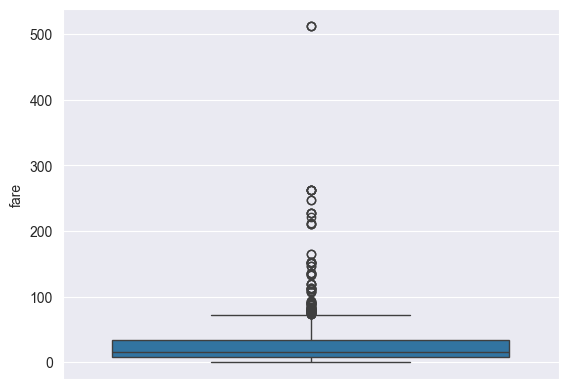

In [27]:
sns.boxplot(data= df_copy, y = 'fare')